<a href="https://colab.research.google.com/github/zehszo/IC-kNN/blob/main/IC_kNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**🎙️ Next Steps: K-Nearest Neighbors (kNN) & Hyperparameter Tuning**

**Objective:** Construct a voice-based gender classification model using the K-Nearest Neighbor classifier.

**Author:** José Pedro Rodrigues de Freitas | Undergraduate Research Project

In this second part, we apply the kNN algorithm to the Voice Gender dataset. While our previous Logistic Regression worked with a linear decision boundary, kNN classifies data based on proximity in the feature space.

**Note on Data Preparation:** The data cleaning process (outlier removal via IQR and multicollinearity filtering) follows the same methodology established in the Logistic Regression aproach. For a detailed breakdown of the cleaning steps, check: https://www.linkedin.com/feed/update/urn:li:activity:7445856147640606721/.

**📥 1. Environment Setup and Data Ingestion**

In this initial phase, we prepare the environment using the fundamental Python ecosystem for Data Science:

**🎲 Pandas & NumPy:** For matrix manipulation and tabular data structures.

**📉 Matplotlib & Seaborn:** For statistical visualization and Exploratory Data Analysis (EDA).

**🤖 Scikit-Learn:** For the end-to-end Machine Learning pipeline (preprocessing, modeling, and evaluation).

Technical Note: The dataset used is the Voice Gender Dataset, which consists of 3,168 samples of male and female voices, pre-processed via acoustic analysis.

In [2]:
# --- Fundamental Libraries ---
import pandas as pd
import numpy as np

# --- Data Visualization ---
import matplotlib.pyplot as plt
import seaborn as sns
from seaborn import heatmap

# --- Preprocessing & Machine Learning ---
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, roc_auc_score

# --- Data Loading ---

try:
    df = pd.read_csv('voice.csv')

    if df['label'].dtype == 'object':
      df['label'] = df['label'].map({'male': 0, 'female': 1})

    X = df.drop('label', axis=1)
    y = df['label']

    print(f"✅ Dataset successfully loaded! Shape: {df.shape}")
    print(f"Missing values: {df.isnull().sum().sum()}")

except FileNotFoundError:
    print("❌ Error: 'voice.csv' not found. Please upload the file to the Colab 'Files' tab.")

✅ Dataset successfully loaded! Shape: (3168, 21)
Missing values: 0


**🧪 2. Baseline Analysis: Performance on Raw Data**

In this section, we establish the model's Baseline by training a standard **k-Nearest Neighbors (kNN)** classifier with default parameters. To ensure a scientifically sound evaluation, we follow a rigorous 70/20/10 split strategy:

**Training Set (70%):** Where the model learns the spatial patterns.

**Validation Set (20%):** Used for monitoring performance before final optimization.

**Test Set (10%):** Reserved as a "final vault" to measure real-world generalization.

Following the data split, we evaluate the model's performance using **Accuracy, Confusion Matrix**, and the **Classification Report** (Precision, Recall, and F1-Score). This initial assessment allows us to measure the impact of untreated data and unoptimized hyperparameters on the model's ability to distinguish between male and female voices.

In [3]:
# --- Initial Data Splitting ---
# 1. Separating the Final Test Set (10%)
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.10, random_state=42)

# 2. Separating Validation (20%) from the remaining 90%
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.2222, random_state=42)

# Verification
print(f"Train: {len(X_train)/len(X):.1%}")
print(f"Validation: {len(X_val)/len(X):.1%}")
print(f"Test: {len(X_test)/len(X):.1%}")

Train: 70.0%
Validation: 20.0%
Test: 10.0%


In [4]:
# 3. Selection, fitting and prediction of kNN model

model = KNeighborsClassifier()
model.fit(X_train, y_train)

Y_pred = model.predict(X_val)

In [5]:
# 4. Accuracy Check
print(f"🎯 Baseline Validation Accuracy: {model.score(X_val, y_val):.4f}")

🎯 Baseline Validation Accuracy: 0.7035


Text(0.5, 1.0, 'Confusion Matrix on Baseline Set')

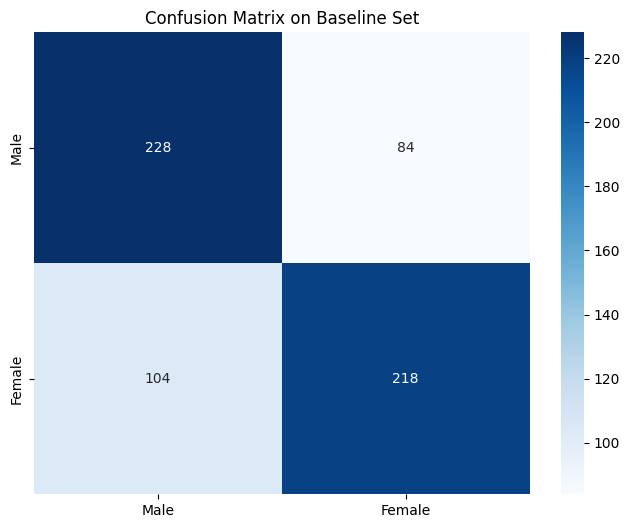

In [6]:
# 5. Plotting the Confusion Matrix Heatmap
cm = confusion_matrix(y_val, Y_pred)
plt.figure(figsize=(8, 6))
heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Male', 'Female'], yticklabels=['Male', 'Female'])
plt.title('Confusion Matrix on Baseline Set')

In [7]:
# 6. Generating the Classification Report
print("\n📋 Baseline Classification Report:")
print(classification_report(y_val, Y_pred))


📋 Baseline Classification Report:
              precision    recall  f1-score   support

           0       0.69      0.73      0.71       312
           1       0.72      0.68      0.70       322

    accuracy                           0.70       634
   macro avg       0.70      0.70      0.70       634
weighted avg       0.70      0.70      0.70       634



**🛠️ 3. Data Refinement & Feature Engineering**

In this phase, we apply a specialized Data Cleaning Pipeline to improve model stability and predictive power. To maintain focus on the kNN implementation, we will not delve into the mathematical specifics of the cleaning process here.

**Methodology Note:** The data treatment follows the exact protocol established in our previous Logistic Regression project, including:

  **1. Multicollinearity Filtering:** Removing redundant features via correlation analysis.

  **2. Outlier Removal:** Applying the Interquartile Range (IQR) method.

  **3. Feature Standardization:** Using StandardScaler to normalize the feature space.

For a deep dive into why these steps are critical for acoustic data, please refer to the detailed documentation in the https://github.com/zehszo/IC-LogisticRegression.

In [8]:
# 1. Correlation-Based Feature Selection

# Calculating absolute correlation matrix
corr_matrix = X.corr().abs()

# Selecting the upper triangle to avoid self-comparison
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Identifying features with correlation > 0.9
to_drop = [column for column in upper.columns if any(upper[column] > 0.9)]

print(f"Redundant columns identified. (Corr > 0.9): {to_drop}")

# Dropping redundant features
X_filtered = X.drop(columns=to_drop)

print(f"Total columns removed: {len(to_drop)}")
print(f"Remaining columns: {list(X_filtered.columns)}")

Redundant columns identified. (Corr > 0.9): ['median', 'Q25', 'kurt', 'centroid', 'dfrange']
Total columns removed: 5
Remaining columns: ['meanfreq', 'sd', 'Q75', 'IQR', 'skew', 'sp.ent', 'sfm', 'mode', 'meanfun', 'minfun', 'maxfun', 'meandom', 'mindom', 'maxdom', 'modindx']


In [9]:
# 2. Outlier Removal via IQR
Q1 = X_filtered.quantile(0.25)
Q3 = X_filtered.quantile(0.75)
IQR = Q3 - Q1

# Define limits
lower_limit = Q1 - 3 * IQR
upper_limit = Q3 + 3 * IQR

# Filtering the dataset
non_outliers_mask = ~((X_filtered < lower_limit) | (X_filtered > upper_limit)).any(axis=1)
df_final = df.loc[non_outliers_mask, list(X_filtered.columns) + ['label']]

print(f"Lines before filter: {len(df)}")
print(f"Linhas after outlier removal: {len(df_final)}")

Lines before filter: 3168
Linhas after outlier removal: 2808


In [10]:
# New sets
X_f = df_final.drop('label', axis=1)
y_f = df_final['label']

# --- Re-splitting Clean Data ---
# Note: X_test remains untouched (from the original raw split) to prove the model's generalization on real-world noisy data later.
X_train_final, X_val_final, y_train_final, y_val_final = train_test_split(X_f, y_f, test_size=0.2222, random_state=42)

# Verification
print(f"Train: {len(X_train_final)/len(X_f):.1%}")
print(f"Validation: {len(X_val)/len(X_f):.1%}")

Train: 77.8%
Validation: 22.6%


In [11]:
# 3. Apllying standardization
scaler = StandardScaler()

# Fit and transform the data
X_train_scaled = scaler.fit_transform(X_train_final)
X_val_scaled = scaler.transform(X_val_final)

# Ensuring we use only the optimized feature set
X_test_final = X_test[list(X_filtered.columns)]
X_test_final_scaled = scaler.transform(X_test_final)

print("✅ Feature Scaling Complete.")

✅ Feature Scaling Complete.


**📊 4. Post-Treatment Performance Evaluation**

With the data cleaned and standardized, we now re-evaluate the model's performance. We follow the same metrics utilized in the baseline analysis—**Accuracy, Confusion Matrix, and Classification Report**—to directly measure the impact of the data refinement process on the model's predictive stability.

In [12]:
# 1. Training and predicting the Refined Model
model.fit(X_train_scaled, y_train_final)
Y_pred = model.predict(X_val_scaled)

In [13]:
# 2. Accuracy Check
print(f"🎯 Refined Validation Accuracy: {accuracy_score(y_val_final, Y_pred):.4f}")

🎯 Refined Validation Accuracy: 0.9663


<Axes: >

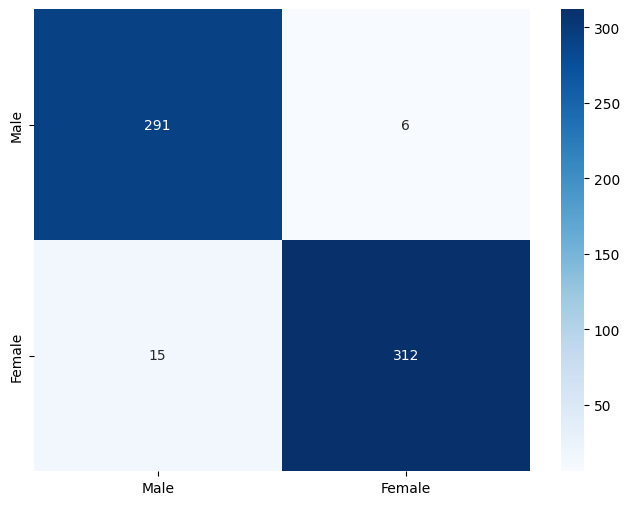

In [14]:
# 3. Plotting the Confusion Matrix Heatmap
cm = confusion_matrix(y_val_final, Y_pred)
plt.figure(figsize=(8, 6))
heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Male', 'Female'], yticklabels=['Male', 'Female'])

In [15]:
# 4. Generating the Classification Report
print("\n📋 Optimized Classification Report:")
print(classification_report(y_val_final, Y_pred))


📋 Optimized Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.98      0.97       297
           1       0.98      0.95      0.97       327

    accuracy                           0.97       624
   macro avg       0.97      0.97      0.97       624
weighted avg       0.97      0.97      0.97       624



In [16]:
# 5. Test with unseen data
Y_pred_final = model.predict(X_test_final_scaled)
print(f"🎯 Final Test Accuracy: {accuracy_score(y_test, Y_pred_final):.4f}")

🎯 Final Test Accuracy: 0.9243


**⚙️ 5. Hyperparameter Tuning via GridSearchCV**

Note that as the model is tested with the unseen data, it shows signs of overfitting, having a lower accuracy than with the validation set (0.9663 to 0.9243). To extract maximum performance from the kNN algorithm, we cannot rely on default settings (such as the fixed $k=5$). In this section, we implement GridSearchCV, an exhaustive search technique that automates the testing of multiple hyperparameter combinations to identify the optimal configuration for our dataset.

**🛠️ Parameters Under Evaluation**

The "Grid" is configured to explore the following dimensions of the model:

- **n_neighbors ($k$):** We will test values from 1 to 49 to find the ideal balance between bias and variance.

- **Weights:** We will evaluate whether all neighbors should have equal influence (uniform) or if closer neighbors should have a greater impact on the classification (distance).

- **Metric & p (Distance Metrics):** We will analyze performance using Euclidean ($p=2$) and Manhattan ($p=1$) distances, which are fundamental in defining "proximity" within the acoustic feature space.

**🔄 Cross-Validation Strategy**

To ensure result robustness and prevent overfitting, we utilize **7-fold Cross-Validation (cv=7).** This means every parameter combination is tested 7 times across different training subsets, ensuring the model generalizes effectively to unseen data.

**📊 Performance Assessment**

Once the best parameter combination is identified, the optimized model will undergo a final verification. We will re-analyze the **Accuracy, Confusion Matrix, and Classification Report** to validate the performance leap compared to our baseline model.

In [23]:
# 1. Parameter tunning with GridSearchCV

model_grid = GridSearchCV(estimator=KNeighborsClassifier(),
                      param_grid={
                          'n_neighbors': [i for i in range(1, 50)],
                          'weights': ['uniform', 'distance'],
                          'metric': ['euclidean', 'manhattan'],
                          'p': [1, 2]
                      },
                      cv=7,
                      n_jobs=-1)

model_grid.fit(X_train_scaled, y_train_final)
Y_pred_grid = model_grid.predict(X_val_scaled)

print("🏆 Best Parameters found by GridSearchCV:")
print(model_grid.best_params_)

print(f"\n🎯 Best Cross-Validation Score: {model_grid.best_score_:.4f}")

🏆 Best Parameters found by GridSearchCV:
{'metric': 'manhattan', 'n_neighbors': 8, 'p': 1, 'weights': 'distance'}

🎯 Best Cross-Validation Score: 0.9766


In [24]:
# 2. Accuracy Check
print(f"🎯 Grid Search Validation Accuracy: {accuracy_score(y_val_final, Y_pred_grid):.4f}")

🎯 Grid Search Validation Accuracy: 0.9696


**🏁 6. Final Model Validation and ROC Analysis**

In this final stage, we put our optimized kNN model to the ultimate test using the **Test Set** (the 10% of data completely isolated at the start of the project). Since these samples were never seen during the training or the GridSearchCV phases, they provide the most accurate estimate of how the model will perform in a real-world scenario.

**📈 Comprehensive Metrics**

To provide a 360-degree view of the model's performance, we evaluate:

- **Accuracy, Precision, Recall, and F1-Score:** To ensure balanced classification between male and female voices.

- **Confusion Matrix:** To visualize specific misclassifications.

- **ROC Curve & AUC (Area Under the Curve):** We include the ROC curve to measure the model's diagnostic ability. The AUC score will tell us the probability that the model ranks a random positive sample higher than a random negative one—a perfect model having an AUC of 1.0.

This final verification confirms whether the combination of rigorous data cleaning and exhaustive hyperparameter tuning resulted in a truly robust and generalized classifier.

In [28]:
# 1. Accuracy check
Y_pred_final = model_grid.predict(X_test_final_scaled)
print(f"🎯 Final Test Accuracy: {accuracy_score(y_test, Y_pred_final):.2f}")

🎯 Final Test Accuracy: 0.99


Text(0.5, 1.0, 'Confusion Matrix on Test Set')

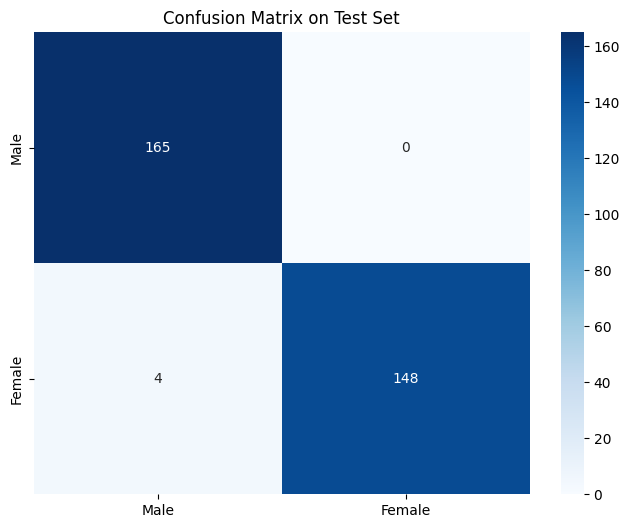

In [30]:
# 2. Confusion Matrix

cm = confusion_matrix(y_test, Y_pred_final)
plt.figure(figsize=(8, 6))
heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Male', 'Female'], yticklabels=['Male', 'Female'])
plt.title('Confusion Matrix on Test Set')

In [31]:
# 3. Classification Report
print("\n📋 Final Classification Report:")
print(classification_report(y_test, Y_pred_final))


📋 Final Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       165
           1       1.00      0.97      0.99       152

    accuracy                           0.99       317
   macro avg       0.99      0.99      0.99       317
weighted avg       0.99      0.99      0.99       317



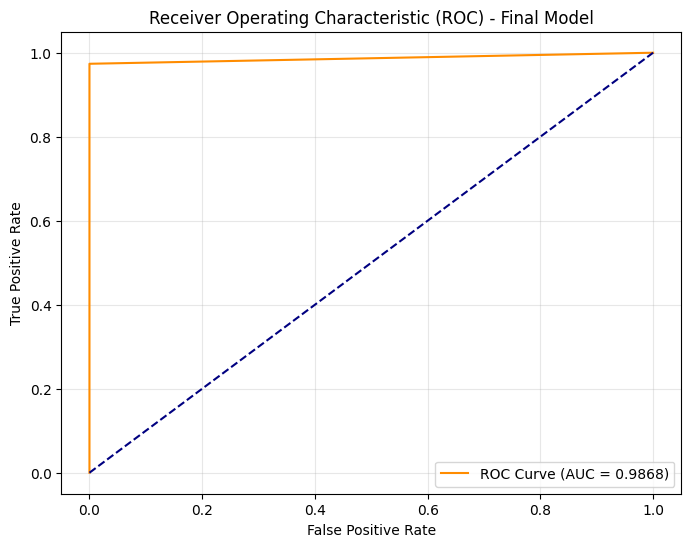

In [32]:
# 4. Plotting ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, Y_pred_final)
auc_score = roc_auc_score(y_test, Y_pred_final)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', label=f'ROC Curve (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--') # Random guess line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) - Final Model')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

**📝 7. Conclusion: The Impact of Engineering and Optimization**

The development of this kNN model highlights a critical principle in Machine Learning: the algorithm is only as good as the data and the tuning behind it. By comparing our initial baseline with the final optimized version, we can draw two major conclusions:

- **Data Quality as a Performance Driver:** The initial data treatment (outlier removal and feature selection) was responsible for a significant leap in accuracy. Removing noise and redundant variables allowed the kNN to calculate distances in a much cleaner feature space, directly improving the model's reliability.

- **Overfitting Reduction through Tuning:** Before optimization, the model showed signs of overfitting, performing well on training data but struggling to maintain the same consistency on validation sets. The implementation of **GridSearchCV** combined with **7-fold Cross-Validation** allowed us to find the "sweet spot" for $k$ and the ideal distance metrics. This systematic tuning ensured that our high accuracy was not a result of "memorization" but of true generalization.

**Final Result:** We successfully transformed a standard classifier into a robust, high-performance model, proving that rigorous data engineering and hyperparameter optimization are indispensable for building trustworthy AI.